# 실습 1: 언어 감지 & 감성 분석
**소요시간: 30분** | 난이도: ⭐⭐

## 학습 목표
1. `detect_dominant_language`로 텍스트의 언어를 자동 감지합니다.
2. `detect_sentiment`로 문서 전체의 감성(긍정/부정/중립/혼합)을 분석합니다.
3. `batch_detect_sentiment`로 여러 문서를 한 번에 처리합니다.

## API 개요
```python
# 언어 감지
comprehend.detect_dominant_language(Text='...')

# 감성 분석
comprehend.detect_sentiment(Text='...', LanguageCode='ko')

# 배치 감성 분석 (최대 25개)
comprehend.batch_detect_sentiment(TextList=[...], LanguageCode='ko')
```

### 감성 결과 구조
```
{
  'Sentiment': 'POSITIVE' | 'NEGATIVE' | 'NEUTRAL' | 'MIXED',
  'SentimentScore': {
    'Positive': 0.98, 'Negative': 0.01,
    'Neutral': 0.01,  'Mixed': 0.00
  }
}
```


---
## 🏢 기업 시나리오 — 글로벌 이커머스 'ShopGlobal' 고객경험(CX)팀

당신은 글로벌 온라인 쇼핑몰의 **CX 데이터 분석가**입니다.
전 세계에서 **하루 수만 건**의 상품 리뷰가 한국어·영어·일본어 등 여러 언어로 쏟아집니다.
사람이 일일이 다 읽는 것은 불가능합니다.

이번 실습에서는 Comprehend로 다음을 자동화합니다.
1. **언어 자동 감지** → 리뷰를 해당 언어 CS팀으로 라우팅
2. **감성 분석** → 부정 리뷰를 가려내 우선 대응 큐로 전달
3. **배치 처리** → 수천 건 리뷰를 한 번의 호출로 대량 분석

> 💡 실무에서는 이 과정을 매일 밤 자동 실행해, 다음 날 아침 CX팀이 '어제의 부정 리뷰 Top 10' 대시보드를 받아봅니다.


In [1]:
# ✅ [제공 코드] 환경 초기화
import boto3, json
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정 (SageMaker Studio) — 최초 1회만 설치, 이후 즉시 로드
try:
    import koreanize_matplotlib
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'koreanize-matplotlib'])
    import koreanize_matplotlib

# Comprehend는 한국어 감성·개체 분석을 지원하므로 서울 리전을 사용합니다
comprehend = boto3.client('comprehend', region_name='ap-northeast-2')
print('✅ Comprehend 클라이언트 생성 완료 (서울 ap-northeast-2)')


✅ Comprehend 클라이언트 생성 완료 (서울 ap-northeast-2)


## ✏️ TODO 1: detect_dominant_language — 언어 감지

다국어 텍스트 목록에서 각 문장의 언어를 자동으로 감지하세요.


In [3]:
# ✏️ TODO 1: 언어 감지 API를 호출하고 결과를 출력하세요
texts = [
    '배송이 빠르고 포장도 꼼꼼했어요. 재구매 의사 있습니다.',
    'The fabric quality is amazing for the price. Highly recommend!',
    'サイズが小さめなので、ワンサイズ大きめがおすすめです。',
    'La couleur est un peu differente de la photo, mais je suis satisfaite.',
]

print('언어 감지 결과:')
print('-' * 55)
for text in texts:
    response = comprehend.detect_dominant_language(
        Text=text  # ← text
    )
    top = response['Languages'][0]
    lang_code = top['LanguageCode']    # ← 'LanguageCode'
    score     = top['Score']    # ← 'Score'
    print(f'  [{lang_code}] {score:.3f}  {text[:30]}')


언어 감지 결과:
-------------------------------------------------------
  [ko] 0.793  배송이 빠르고 포장도 꼼꼼했어요. 재구매 의사 있습니다
  [en] 0.974  The fabric quality is amazing 
  [ja] 1.000  サイズが小さめなので、ワンサイズ大きめがおすすめです。
  [fr] 0.997  La couleur est un peu differen


## ✏️ TODO 2: detect_sentiment — 단일 문서 감성 분석

리뷰 텍스트의 감성과 각 감성 점수를 출력하세요.


In [4]:
# ✏️ TODO 2: 감성 분석 API를 호출하고 결과를 출력하세요
reviews = [
    '이 제품 정말 최고예요! 배송도 빠르고 품질도 훌륭합니다.',
    '완전 실망입니다. 사진과 너무 다르고 품질이 형편없어요.',
    '그냥 평범한 제품이에요. 나쁘지도 좋지도 않습니다.',
    '좋은 점도 있고 아쉬운 점도 있어요. 가격 대비는 괜찮네요.',
]

results = []
for review in reviews:
    response = comprehend.detect_sentiment(
        Text=review,           # ← review
        LanguageCode='ko'    # ← 'ko'
    )
    sentiment = response['Sentiment']        # ← 'Sentiment'
    scores    = response['SentimentScore']        # ← 'SentimentScore'
    results.append({'text': review[:25], 'sentiment': sentiment, 'scores': scores})
    print(f'  {sentiment:<10} | {review[:30]}')

print('\n상세 점수 (첫 번째 리뷰):')
for k, v in results[0]['scores'].items():
    print(f'  {k:<12}: {v:.4f}')


  POSITIVE   | 이 제품 정말 최고예요! 배송도 빠르고 품질도 훌륭합니
  NEGATIVE   | 완전 실망입니다. 사진과 너무 다르고 품질이 형편없어요
  NEGATIVE   | 그냥 평범한 제품이에요. 나쁘지도 좋지도 않습니다.
  POSITIVE   | 좋은 점도 있고 아쉬운 점도 있어요. 가격 대비는 괜찮

상세 점수 (첫 번째 리뷰):
  Positive    : 0.9999
  Negative    : 0.0001
  Neutral     : 0.0001
  Mixed       : 0.0000


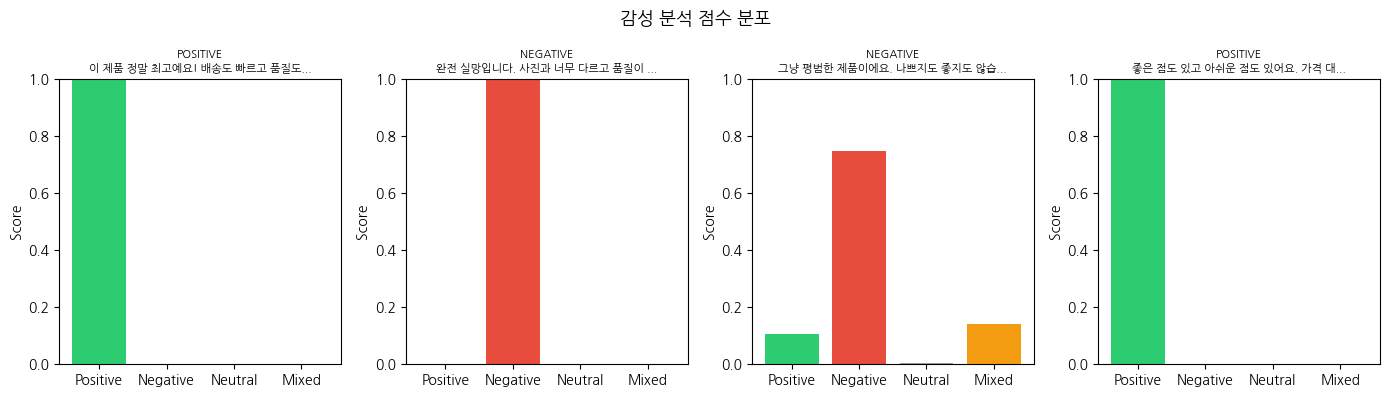

In [5]:
# ✅ [제공 코드] 감성 점수 시각화
fig, axes = plt.subplots(1, len(results), figsize=(14, 4))
colors = {'POSITIVE':'#2ecc71','NEGATIVE':'#e74c3c','NEUTRAL':'#95a5a6','MIXED':'#f39c12'}
labels = ['Positive','Negative','Neutral','Mixed']
for ax, r in zip(axes, results):
    vals = [r['scores']['Positive'], r['scores']['Negative'],
            r['scores']['Neutral'],  r['scores']['Mixed']]
    bar_colors = [colors[l.upper()] for l in labels]
    ax.bar(labels, vals, color=bar_colors)
    ax.set_title(f"{r['sentiment']}\n{r['text']}...", fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
plt.suptitle('감성 분석 점수 분포', fontsize=13)
plt.tight_layout()
plt.show()


## ✏️ TODO 3: batch_detect_sentiment — 배치 처리

여러 문서를 한 번의 API 호출로 처리하고 결과를 DataFrame으로 정리하세요.


In [7]:
# ✏️ TODO 3: batch_detect_sentiment로 여러 문서를 한 번에 분석하세요
batch_texts = [
    '사이즈가 딱 맞고 색상도 화면이랑 똑같아요.',
    '배송이 일주일 넘게 걸렸어요. 너무 느립니다.',
    '가성비 최고입니다. 친구에게도 추천했어요.',
    '주문한 색상과 다른 색이 왔어요. 교환 요청합니다.',
    '품질 대비 가격이 합리적이에요. 만족합니다.',
]

response = comprehend.batch_detect_sentiment(
    TextList=batch_texts,       # ← batch_texts
    LanguageCode='ko'    # ← 'ko'
)

rows = []
for item in response['ResultList']:  # ← 'ResultList'
    idx  = item['Index']
    sent = item['Sentiment']
    pos  = item['SentimentScore']['Positive']
    neg  = item['SentimentScore']['Negative']
    rows.append({'텍스트': batch_texts[idx][:20], '감성': sent,
                 'Positive': round(pos,3), 'Negative': round(neg,3)})

df = pd.DataFrame(rows)
print(df.to_string(index=False))


                 텍스트       감성  Positive  Negative
사이즈가 딱 맞고 색상도 화면이랑 똑 POSITIVE     0.994     0.002
배송이 일주일 넘게 걸렸어요. 너무  NEGATIVE     0.000     1.000
가성비 최고입니다. 친구에게도 추천했 POSITIVE     1.000     0.000
주문한 색상과 다른 색이 왔어요. 교 NEGATIVE     0.013     0.958
품질 대비 가격이 합리적이에요. 만족 POSITIVE     1.000     0.000


---
## 🔗 실무로 연결하기

오늘 만든 3개의 분석(언어감지 → 감성 → 배치)이 실제 서비스에서는 이렇게 연결됩니다.

`S3(리뷰 적재)` → `Lambda(Comprehend 호출)` → `DynamoDB/RDS(결과 저장)` → `대시보드/알림`

- 부정 감성 + 높은 신뢰도 리뷰는 **Slack 알림**으로 CS 리더에게 즉시 전달
- 언어별 리뷰 비율을 집계하면 **어느 국가 시장이 성장 중인지** 한눈에 파악
- 사람이 읽는 시간을 줄여 **CS 대응 속도(SLA)** 를 단축


## 💡 심화 도전
1. 영어 텍스트와 한국어 텍스트의 감성 분석 결과를 비교해보세요.
2. 부정적 리뷰만 필터링하여 Confidence가 높은 순으로 정렬해보세요.
3. 실제 상품 리뷰 10개를 입력하여 긍정/부정 비율을 파이차트로 시각화하세요.


## ✅ 정답 코드

👆 모두 풀고 난 후 확인하세요

```python
# TODO 1
response = comprehend.detect_dominant_language(Text=text)
lang_code = top['LanguageCode']
score     = top['Score']

# TODO 2
response = comprehend.detect_sentiment(Text=review, LanguageCode='ko')
sentiment = response['Sentiment']
scores    = response['SentimentScore']

# TODO 3
response = comprehend.batch_detect_sentiment(TextList=batch_texts, LanguageCode='ko')
for item in response['ResultList']:
```
